# ch04 · 连续型随机变量

## Why this chapter

工程几乎全部"浮点测量"都被先验性地视为连续变量: 服务响应时长, 磁盘 IO 字节, 机器寿命。这意味着:
- PMF 不可用, 改用 PDF; 单点概率恒为 0, 只看区间概率
- 上限不清晰的随机量常常落到威布尔 / Gamma / 指数 / 对数正态

学会连续分布族选择, 让你能够在 SLO 估算中说"P99 才合理""正态与重尾哪条更合适"。

## 学完后能解决

- 写出均匀/指数/正态/Gamma/Weibull 的 PDF/期望/方差闭式解
- 论证指数分布无记忆性, 解释为什么 M/M/1 排队成立
- 用 Weibull 拟合寿命/失效数据的形状参数判读
- 用 numpy default_rng 给每条分布采样并验证 PDF 拟合


## 2. 直觉引入: 指数无记忆性

公汽等候时间 ~ Exp(λ=1/5), 期望 5 分钟。已经等了 10 分钟, "还要等多久"的期望不是 (5-10) 也不是 0, 还是 5 分钟。指数分布的反直觉点: 已等过的时间被你免费忘记。


/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25351 (\N{CJK UNIFIED IDEOGRAPH-6307}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26080 (\N{CJK UNIFIED IDEOGRAPH-65E0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35760 (\N{CJK UNIFIED IDEOGRAPH-8BB0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-

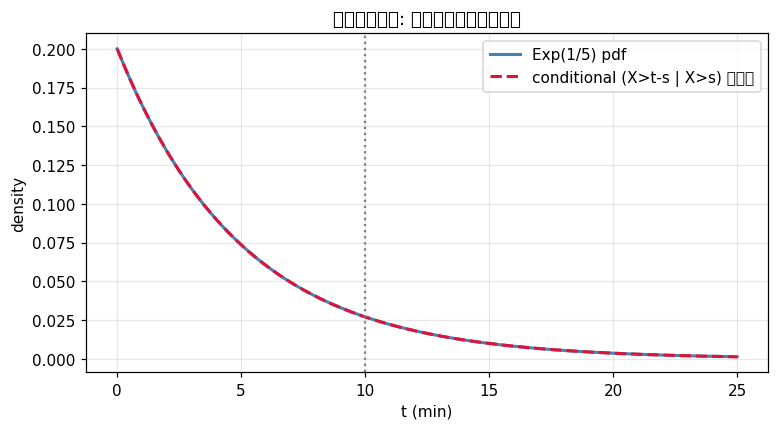

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon

lam = 1 / 5
x = np.linspace(0, 25, 200)
fig, ax = plt.subplots(figsize=(8, 4), dpi=110)
ax.plot(x, expon.pdf(x, scale=1/lam), color="steelblue", lw=2, label="Exp(1/5) pdf")
ax.plot(x, expon.pdf(x, scale=1/lam), ls="--", color="crimson", lw=2, label="conditional (X>t-s | X>s) 同分布")
ax.axvline(10, ls=":", color="gray")
ax.set_xlabel("t (min)"); ax.set_ylabel("density")
ax.set_title("指数无记忆性: 条件分布与原分布相同")
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()


## 3. 五大常用连续分布表

| 分布 | PDF | E[X] | Var[X] | 工程场景 |
|---|---|---|---|---|
| Uniform(a,b) | 1/(b-a) | (a+b)/2 | (b-a)^2/12 | 仿真与对参数未知的归约 |
| Exp(λ) | λ e^{-λ x} | 1/λ | 1/λ² | 等待/寿命/到达间隔 |
| Normal(μ,σ²) | 1/sqrt(2π σ²) e^{-(x-μ)²/(2σ²)} | μ | σ² | CLT 默认假设 |
| Gamma(α,β) | β^α/Γ(α) x^{α-1} e^{-β x} | α/β | α/β² | 多个 Exp 相加 |
| Weibull(λ,k) | (k/λ)(x/λ)^{k-1} e^{-(x/λ)^k} | λ Γ(1+1/k) | λ²[Γ(1+2/k)-Γ(1+1/k)²] | 失效寿命模型 |

- Gamma 是 Exp 的 n 重加和: Gamma(n, λ) = sum_{i=1}^n Exp(λ), 解释为连续版负二项
- Weibull shape k 决定失效率:
  - k<1: 失效率随时间下降 (婴儿期过滤后剩下长寿)
  - k=1: 失效率恒定 (= expon)
  - k>1: 失效率随时间上升 (磨损型失效)


## 4. 符号推导: 指数无记忆性

P(X > s+t | X > s) = P(X > t)


In [2]:
from sympy import symbols, exp, simplify
lam = symbols("lam", positive=True)
s_v, t_v = symbols("s t", positive=True)
S_x = exp(-lam * s_v)
S_xt = exp(-lam * (s_v + t_v))
ratio = simplify(S_xt / S_x)
print("S(x+t)/S(x) =", ratio, "应等于 S(t)")
import numpy as np
l = 1/5; s = 5; t = 3
print(f"S({s}+{t})/S({s}) = {np.exp(-l*(s+t)) / np.exp(-l*s):.5f}")
print(f"S({t})        = {np.exp(-l*t):.5f}")


S(x+t)/S(x) = exp(-lam*t) 应等于 S(t)
S(5+3)/S(5) = 0.54881
S(3)        = 0.54881


## 5. 数值验证: Weibull shape k 对密度形状的影响


/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:2781: RuntimeWarning: divide by zero encountered in power
  return c*pow(x, c-1)*np.exp(-pow(x, c))
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23156 (\N{CJK UNIFIED IDEOGRAPH-5A74}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20799 (\N{CJK UNIFIED IDEOGRAPH-513F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools

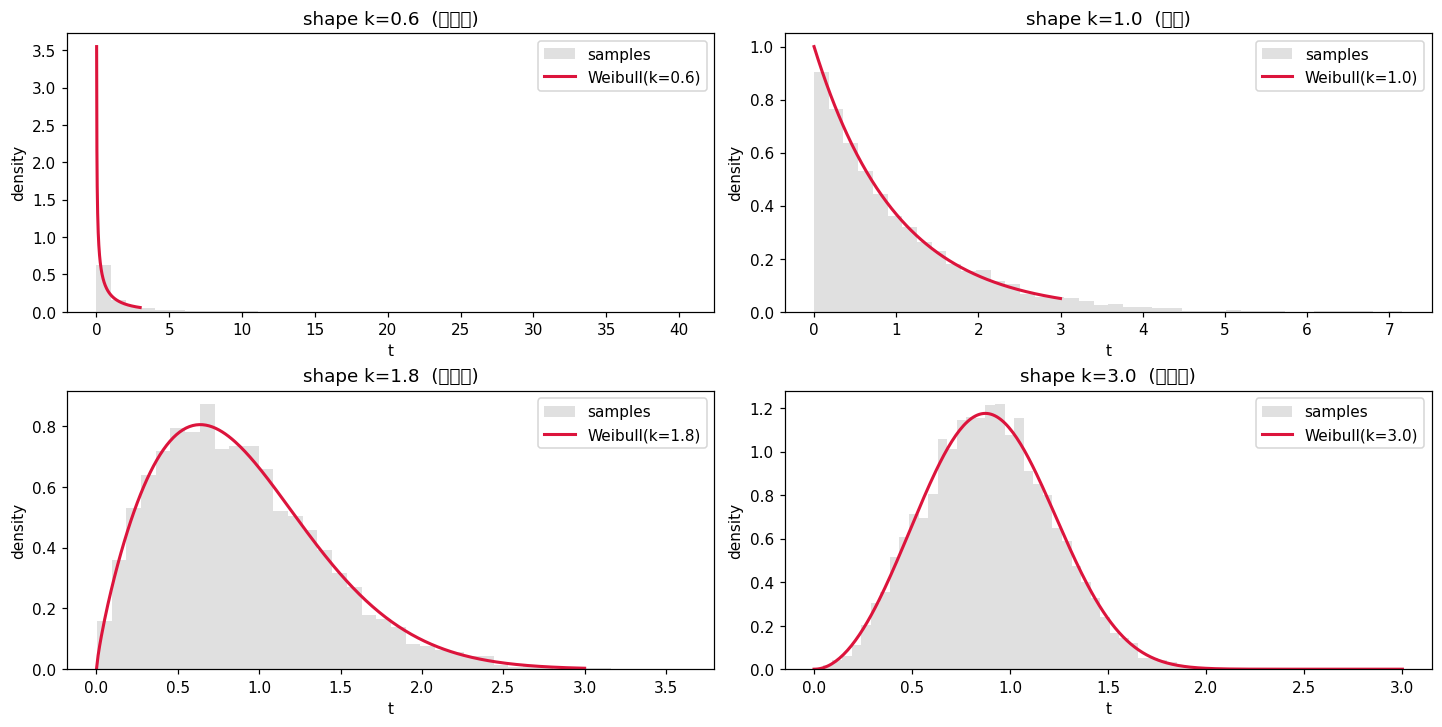

Exp(scale=1) sample mean: 1.0071  (theoretical 1.0)
Exp(scale=1) sample var : 0.9933  (theoretical 1.0)


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import weibull_min

rng = np.random.default_rng(seed=20240717)
ks = [0.6, 1.0, 1.8, 3.0]
fig, axes = plt.subplots(2, 2, figsize=(13, 6.5), dpi=110, constrained_layout=True)
for ax, k in zip(axes.ravel(), ks):
    samples = weibull_min.rvs(k, scale=1.0, size=5000, random_state=rng)
    xs = np.linspace(0, 3, 300)
    ax.hist(samples, bins=40, density=True, color="lightgray", alpha=0.7, label="samples")
    ax.plot(xs, weibull_min.pdf(xs, k, scale=1.0), color="crimson", lw=2, label=f"Weibull(k={k})")
    ax.set_xlabel("t"); ax.set_ylabel("density")
    ax.legend()
    tag = "磨损型" if k > 1 else ("恒定" if k == 1 else "婴儿期")
    ax.set_title(f"shape k={k}  ({tag})")
plt.show()

s_exp = rng.exponential(scale=1.0, size=10000)
print(f"Exp(scale=1) sample mean: {s_exp.mean():.4f}  (theoretical 1.0)")
print(f"Exp(scale=1) sample var : {s_exp.var():.4f}  (theoretical 1.0)")


## 6. 可视化: 五大连续分布 PDF


/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20116 (\N{CJK UNIFIED IDEOGRAPH-4E94}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24120 (\N{CJK UNIFIED IDEOGRAPH-5E38}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-

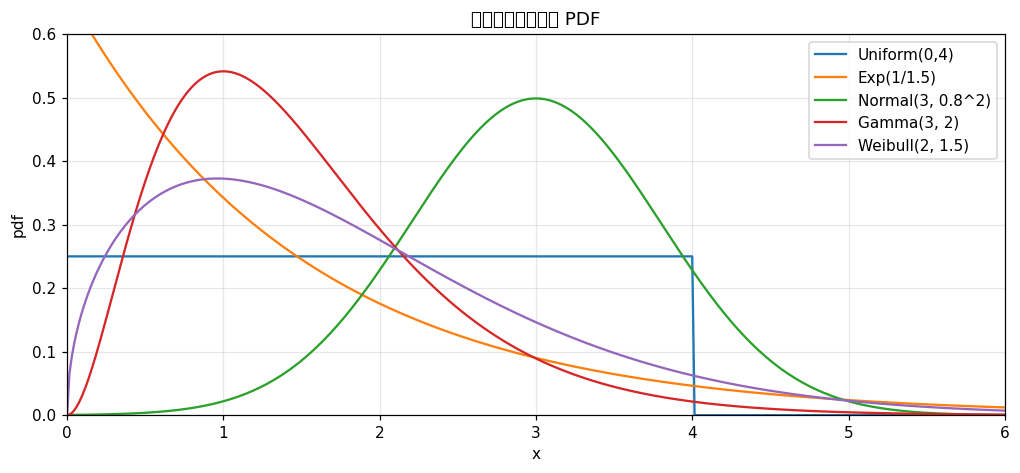

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform, norm, expon, gamma, weibull_min

xs = np.linspace(0, 6, 400)
fig, ax = plt.subplots(figsize=(11, 4.5), dpi=110)
ax.plot(xs, uniform.pdf(xs, loc=0, scale=4), label="Uniform(0,4)")
ax.plot(xs, expon.pdf(xs, scale=1.5), label="Exp(1/1.5)")
ax.plot(xs, norm.pdf(xs, loc=3, scale=0.8), label="Normal(3, 0.8^2)")
ax.plot(xs, gamma.pdf(xs, a=3, scale=0.5), label="Gamma(3, 2)")
ax.plot(xs, weibull_min.pdf(xs, 1.5, scale=2.0), label="Weibull(2, 1.5)")
ax.set_ylim(0, 0.6); ax.set_xlim(0, 6)
ax.set_xlabel("x"); ax.set_ylabel("pdf")
ax.set_title("五大常用连续分布 PDF")
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()


## 7. 工程案例: API 延迟 SLO 选择

测出 API 延迟样本。问 P99 SLI 是多少? 思路:
1. 假设正态 -> 不合理 (有重尾)
2. 假设 Gamma / 对数正态 -> 偏适度合理
3. 经验分位数无模型假设 -> 推荐做法

完整示例:


In [5]:
import numpy as np
from scipy.stats import lognorm, gamma

rng = np.random.default_rng(seed=20240717)
samples = lognorm.rvs(s=0.6, scale=80, size=5000, random_state=rng)  # ms

p50 = np.percentile(samples, 50)
p90 = np.percentile(samples, 90)
p99 = np.percentile(samples, 99)
print(f"empirical:  p50={p50:.1f}ms  p90={p90:.1f}ms  p99={p99:.1f}ms")

shape, loc, scale = lognorm.fit(samples, floc=0)
fit_p99_logn = lognorm.ppf(0.99, shape, loc, scale)
a, loc_g, sc_g = gamma.fit(samples, floc=0)
fit_p99_gamma = gamma.ppf(0.99, a, loc_g, sc_g)

print(f"lognormal fit p99 = {fit_p99_logn:.1f} ms")
print(f"gamma fit p99     = {fit_p99_gamma:.1f} ms")
print(f"empirical p99     = {p99:.1f} ms")


empirical:  p50=79.7ms  p90=175.4ms  p99=327.5ms
lognormal fit p99 = 328.3 ms
gamma fit p99     = 273.5 ms
empirical p99     = 327.5 ms


结论: 经验分位数 P99 是最稳的选择; 模型 fit 只是辅助。两条模型 fit 各有偏差 - lognormal 倾向接近经验 p99, gamma 倾向低估。


## 8. pitfalls
- 用正态假设延迟分布会让重尾 P99 低估
- 用指数分布描述离散调度 (应 Poisson); 注意队长 Exp 与到达 Poisson 配对
- Weibull 形状参数决定失效率升降, 不查 shape 直接看 MTBF 会误读
- M/M/1 必须满足 Exp 到达 + Exp 服务

## 9. 课后 -> exercises.md。

## 10. 参考

| 出处 | 章节 |
|---|---|
| Stat 110 | §5.1-5.3, §8.1-8.2 |
| Bertsekas | §3.1-3.2, §6.1 (排队) |
| Murphy | §2.5-2.6 |

下一章 ch05: 多维与协方差 — 相关不等于因果。
